<a href="https://colab.research.google.com/github/AlexJurcich/Predicting-Housing-Prices/blob/main/Predicting_House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Housing Prices**

## Alex Jurcich

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV, train_test_split, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import data
train_df = pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/test.csv')

In [3]:
# Preview Data
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Columns
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## **Ames Housing Dataset — Variable Reference**

## Identification
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 0 | Id | int64 | Unique identifier for each house |

---

## Zoning & Location
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 2 | MSZoning | object | General zoning classification |
| 12 | Neighborhood | object | Physical location within Ames city limits |
| 13 | Condition1 | object | Proximity to main road, railroad, or positive feature |
| 14 | Condition2 | object | Second proximity condition if more than one applies |
| 5 | Street | object | Type of road access |
| 6 | Alley | object | Type of alley access |

---

## Lot & Land
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 3 | LotFrontage | float64 | Linear feet of street connected to property |
| 4 | LotArea | int64 | Lot size in square feet |
| 7 | LotShape | object | General shape of property |
| 10 | LotConfig | object | Lot configuration |
| 8 | LandContour | object | Flatness of the property |
| 11 | LandSlope | object | Slope of property |

---

## Building & Structure
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 1 | MSSubClass | int64 | Type of dwelling — treat as categorical |
| 15 | BldgType | object | Type of dwelling |
| 16 | HouseStyle | object | Style of dwelling |
| 17 | OverallQual | int64 | Overall material and finish quality rated 1 to 10 |
| 18 | OverallCond | int64 | Overall condition of the house rated 1 to 10 |
| 19 | YearBuilt | int64 | Original construction year |
| 20 | YearRemodAdd | int64 | Remodel year |
| 9 | Utilities | object | Type of utilities available |
| 55 | Functional | object | Home functionality rating |

---

## Roof
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 21 | RoofStyle | object | Type of roof |
| 22 | RoofMatl | object | Roof material |

---

## Exterior
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 23 | Exterior1st | object | Exterior covering on house |
| 24 | Exterior2nd | object | Exterior covering if more than one material |
| 25 | MasVnrType | object | Masonry veneer type |
| 26 | MasVnrArea | float64 | Masonry veneer area in square feet |
| 27 | ExterQual | object | Quality of exterior material |
| 28 | ExterCond | object | Current condition of exterior material |

---

## Foundation & Basement
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 29 | Foundation | object | Type of foundation |
| 30 | BsmtQual | object | Height and quality of basement |
| 31 | BsmtCond | object | General condition of basement |
| 32 | BsmtExposure | object | Walkout or garden level walls |
| 33 | BsmtFinType1 | object | Quality of first finished basement area |
| 34 | BsmtFinSF1 | int64 | Type 1 finished basement square feet |
| 35 | BsmtFinType2 | object | Quality of second finished basement area |
| 36 | BsmtFinSF2 | int64 | Type 2 finished basement square feet |
| 37 | BsmtUnfSF | int64 | Unfinished basement square feet |
| 38 | TotalBsmtSF | int64 | Total basement square feet |
| 47 | BsmtFullBath | int64 | Full bathrooms in basement |
| 48 | BsmtHalfBath | int64 | Half bathrooms in basement |

---

## Heating & Utilities
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 39 | Heating | object | Type of heating system |
| 40 | HeatingQC | object | Heating quality and condition |
| 41 | CentralAir | object | Central air conditioning |
| 42 | Electrical | object | Electrical system type |

---

## Above Ground Living Area
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 43 | 1stFlrSF | int64 | First floor square feet |
| 44 | 2ndFlrSF | int64 | Second floor square feet |
| 45 | LowQualFinSF | int64 | Low quality finished square feet |
| 46 | GrLivArea | int64 | Above grade living area square feet |

---

## Bathrooms & Rooms
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 49 | FullBath | int64 | Full bathrooms above grade |
| 50 | HalfBath | int64 | Half bathrooms above grade |
| 51 | BedroomAbvGr | int64 | Bedrooms above grade |
| 52 | KitchenAbvGr | int64 | Kitchens above grade |
| 53 | KitchenQual | object | Kitchen quality |
| 54 | TotRmsAbvGrd | int64 | Total rooms above grade |

---

## Fireplace
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 56 | Fireplaces | int64 | Number of fireplaces |
| 57 | FireplaceQu | object | Fireplace quality |

---

## Garage
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 58 | GarageType | object | Garage location and type |
| 59 | GarageYrBlt | float64 | Year garage was built |
| 60 | GarageFinish | object | Interior finish of garage |
| 61 | GarageCars | int64 | Garage capacity in car spaces |
| 62 | GarageArea | int64 | Garage size in square feet |
| 63 | GarageQual | object | Garage quality |
| 64 | GarageCond | object | Garage condition |
| 65 | PavedDrive | object | Paved driveway type |

---

## Outdoor Features
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 66 | WoodDeckSF | int64 | Wood deck area in square feet |
| 67 | OpenPorchSF | int64 | Open porch area in square feet |
| 68 | EnclosedPorch | int64 | Enclosed porch area in square feet |
| 69 | 3SsnPorch | int64 | Three season porch area in square feet |
| 70 | ScreenPorch | int64 | Screen porch area in square feet |
| 71 | PoolArea | int64 | Pool area in square feet |
| 72 | PoolQC | object | Pool quality |
| 73 | Fence | object | Fence quality |

---

## Miscellaneous
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 74 | MiscFeature | object | Miscellaneous feature not covered elsewhere |
| 75 | MiscVal | int64 | Dollar value of miscellaneous feature |

---

## Sale Information
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 76 | MoSold | int64 | Month sold |
| 77 | YrSold | int64 | Year sold |
| 78 | SaleType | object | Type of sale |
| 79 | SaleCondition | object | Condition of sale |

---

## Target Variable
| # | Column | Dtype | Description |
|---|--------|-------|-------------|
| 80 | SalePrice | int64 | Sale price of the home in dollars |

## **Data Preprocessing**

In [5]:
# Examine each column for inconsistancies
def quality_check(col):
  # Output
  results = {
      'column': col.name,
      'dtype': str(col.dtype),
      'total_rows': len(col),
      'null_count': col.isnull().sum(),
      'null_pct': round(col.isnull().mean() * 100, 2),
      'unique_count': col.nunique(),
      'duplicates': col.duplicated().sum()
  }

  # Add additional info for numeric columns
  if pd.api.types.is_numeric_dtype(col):
    results.update({
          'mean': col.mean(),
          'median': col.median(),
          'std': col.std(),
          'min': col.min(),
          'max': col.max(),
          'zeros': (col == 0).sum(),
          'negatives': (col < 0).sum()
    })

    # Add additional info for object columns
  elif pd.api.types.is_object_dtype(col):
      results.update({
          'value_counts': col.value_counts().to_dict(),
          'empty_strings': (col == "").sum()
      })

  return results

In [6]:
for col in train_df.columns:
  report = quality_check(train_df[col])
  print(f"\n--- {col} ---")
  for k, v in report.items():
    print(f"{k}:  {v}")


--- Id ---
column:  Id
dtype:  int64
total_rows:  1460
null_count:  0
null_pct:  0.0
unique_count:  1460
duplicates:  0
mean:  730.5
median:  730.5
std:  421.6100093688479
min:  1
max:  1460
zeros:  0
negatives:  0

--- MSSubClass ---
column:  MSSubClass
dtype:  int64
total_rows:  1460
null_count:  0
null_pct:  0.0
unique_count:  15
duplicates:  1445
mean:  56.897260273972606
median:  50.0
std:  42.30057099381035
min:  20
max:  190
zeros:  0
negatives:  0

--- MSZoning ---
column:  MSZoning
dtype:  object
total_rows:  1460
null_count:  0
null_pct:  0.0
unique_count:  5
duplicates:  1455
value_counts:  {'RL': 1151, 'RM': 218, 'FV': 65, 'RH': 16, 'C (all)': 10}
empty_strings:  0

--- LotFrontage ---
column:  LotFrontage
dtype:  float64
total_rows:  1460
null_count:  259
null_pct:  17.74
unique_count:  110
duplicates:  1349
mean:  70.04995836802665
median:  69.0
std:  24.284751774483183
min:  21.0
max:  313.0
zeros:  0
negatives:  0

--- LotArea ---
column:  LotArea
dtype:  int64
total_r

### **Ames Housing Dataset — Preprocessing Checklist**

---

## Drop
Id

---

## Change Data Type (int64 → categorical)
MSSubClass, OverallQual, OverallCond, MoSold, YrSold

---

## Handle Nulls

### Drop column (null % too high)
Alley (93.77%), PoolQC (99.52%), MiscFeature (96.3%), Fence (80.75%)

### Fill with "None" (null means feature does not exist)
MasVnrType (59.73%), FireplaceQu (47.26%), GarageType (5.55%), GarageFinish (5.55%), GarageQual (5.55%), GarageCond (5.55%), BsmtQual (2.53%), BsmtCond (2.53%), BsmtExposure (2.6%), BsmtFinType1 (2.53%), BsmtFinType2 (2.6%)

### Fill with 0 (null means no area/value)
MasVnrArea (0.55%), GarageYrBlt (5.55%)

### Fill with median
LotFrontage (17.74%)

### Fill with mode
Electrical (0.07%)

---

## Ordinal Encoding (Ex=5, Gd=4, TA=3, Fa=2, Po=1, None=0)
ExterQual, ExterCond, BsmtQual, BsmtCond, HeatingQC, KitchenQual, FireplaceQu, GarageQual, GarageCond

### Custom ordinal mapping
BsmtExposure (Gd=4, Av=3, Mn=2, No=1, None=0)
BsmtFinType1, BsmtFinType2 (GLQ=6, ALQ=5, BLQ=4, Rec=3, LwQ=2, Unf=1, None=0)
GarageFinish (Fin=3, RFn=2, Unf=1, None=0)
LotShape (Reg=4, IR1=3, IR2=2, IR3=1)
LandSlope (Gtl=3, Mod=2, Sev=1)
Functional (Typ=7, Min1=6, Min2=5, Mod=4, Maj1=3, Maj2=2, Sev=1)
PavedDrive (Y=3, P=2, N=1)

---

## One-Hot Encoding (nominal categoricals)
MSZoning, Street, LotConfig, LandContour, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, Foundation, Heating, CentralAir, Electrical, GarageType, SaleType, SaleCondition

---

## Low Variance — Possibly Drop
Street (Pave: 1454 vs Grvl: 6), Utilities (AllPub: 1459 vs NoSeWa: 1), RoofMatl (CompShg: 1434, everything else <12), Heating (GasA: 1428, everything else <20), Condition2 (Norm: 1445, everything else <7)

In [7]:
# Create a copy of the data
train_raw = train_df.copy()
test_raw = test_df.copy()

### **Drop ID**

In [8]:
# Drop ID
train_df.drop('Id', axis=1, inplace=True)
test_df.drop('Id', axis=1, inplace=True)

### **Change Data Type**

In [9]:
# Convert from Int64 to Categorical
cols_to_change = ['MSSubClass', 'OverallQual', 'OverallCond', 'MoSold', 'YrSold']

train_df[cols_to_change] = train_df[cols_to_change].astype('object')
test_df[cols_to_change] = test_df[cols_to_change].astype('object')

### **Handle Nulls**

In [10]:
# Drop the columns that are majority nulls
columns_to_drop = ['Alley', 'PoolQC', 'MiscFeature', 'Fence']

for col in columns_to_drop:
  train_df.drop(col, axis=1, inplace=True)
  test_df.drop(col, axis=1, inplace=True)

In [11]:
# Filling with 'None' because null indicates the feature does not exist, not missing data
fill_none_cols = [
    'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]

train_df[fill_none_cols] = train_df[fill_none_cols].fillna('None')
test_df[fill_none_cols] = test_df[fill_none_cols].fillna('None')

In [12]:
# Filling with 0 because null indicates no area or value, not missing data
fill_zero_cols = ['MasVnrArea', 'GarageYrBlt']

train_df[fill_zero_cols] = train_df[fill_zero_cols].fillna(0)
test_df[fill_zero_cols] = test_df[fill_zero_cols].fillna(0)

In [13]:
# Filling with median because null is likely missing data rather than a meaningful absence
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].median())
test_df['LotFrontage'] = test_df['LotFrontage'].fillna(train_df['LotFrontage'].median())

In [14]:
# Filling with mode because only 1 null exists and SBrkr is overwhelmingly dominant
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
test_df['Electrical'] = test_df['Electrical'].fillna(train_df['Electrical'].mode()[0])

### **Ordinal Encoding**

In [15]:
# Ordinal encoding where Ex=5, Gd=4, TA=3, Fa=2, Po=1, None=0
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond'
]

train_df[ordinal_cols] = train_df[ordinal_cols].apply(lambda x: x.map(qual_map))
test_df[ordinal_cols] = test_df[ordinal_cols].apply(lambda x: x.map(qual_map))

In [16]:
# Custom Ordinal Encoding — unique ordering per column
bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
garage_finish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
lot_shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
land_slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
functional_map = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1}
paved_drive_map = {'Y': 3, 'P': 2, 'N': 1}

train_df['BsmtExposure'] = train_df['BsmtExposure'].map(bsmt_exposure_map)
train_df['BsmtFinType1'] = train_df['BsmtFinType1'].map(bsmt_fin_map)
train_df['BsmtFinType2'] = train_df['BsmtFinType2'].map(bsmt_fin_map)
train_df['GarageFinish'] = train_df['GarageFinish'].map(garage_finish_map)
train_df['LotShape'] = train_df['LotShape'].map(lot_shape_map)
train_df['LandSlope'] = train_df['LandSlope'].map(land_slope_map)
train_df['Functional'] = train_df['Functional'].map(functional_map)
train_df['PavedDrive'] = train_df['PavedDrive'].map(paved_drive_map)

test_df['BsmtExposure'] = test_df['BsmtExposure'].map(bsmt_exposure_map)
test_df['BsmtFinType1'] = test_df['BsmtFinType1'].map(bsmt_fin_map)
test_df['BsmtFinType2'] = test_df['BsmtFinType2'].map(bsmt_fin_map)
test_df['GarageFinish'] = test_df['GarageFinish'].map(garage_finish_map)
test_df['LotShape'] = test_df['LotShape'].map(lot_shape_map)
test_df['LandSlope'] = test_df['LandSlope'].map(land_slope_map)
test_df['Functional'] = test_df['Functional'].map(functional_map)
test_df['PavedDrive'] = test_df['PavedDrive'].map(paved_drive_map)

## **EDA**

### **Distribution plots for numeric data**

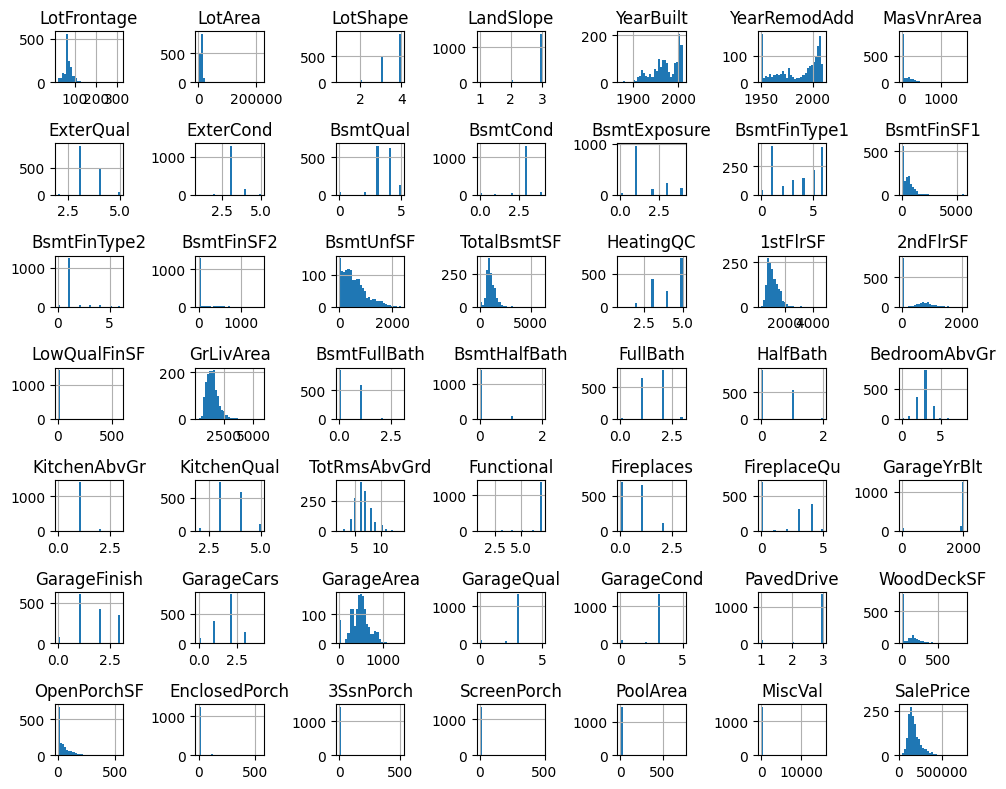

In [17]:
train_df.hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

SalePrice is right skewed with most homes selling between 100k-200k and a long tail up to $755k. Log transforming it produces a near normal distribution which will benefit modeling.

Size related features like LotArea, GrLivArea, TotalBsmtSF, and 1stFlrSF are all right skewed as expected — larger homes are less common. These should be log transformed before modeling.
Ordinal encoded columns like ExterQual, BsmtQual, KitchenQual, and HeatingQC show discrete spikes which is expected since they only have 5 possible values. These are fine as is.

Zero inflated columns like WoodDeckSF, OpenPorchSF, EnclosedPorch, BsmtFinSF2, and MiscVal have a large spike at zero because many homes simply do not have those features. Log1p transformation will handle these.
Year columns like YearBuilt and YearRemodAdd show a left skew with more recent builds being more common, which makes sense for a dataset from 2006-2010. No transformation needed.

GarageYrBlt has a large spike at zero because we filled nulls with 0 for homes with no garage. Worth keeping in mind when interpreting that column.

### **Distribution with log transformation**

In [18]:
# TotalSF — Total square footage of the entire home
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']
test_df['TotalSF'] = test_df['TotalBsmtSF'] + test_df['1stFlrSF'] + test_df['2ndFlrSF']

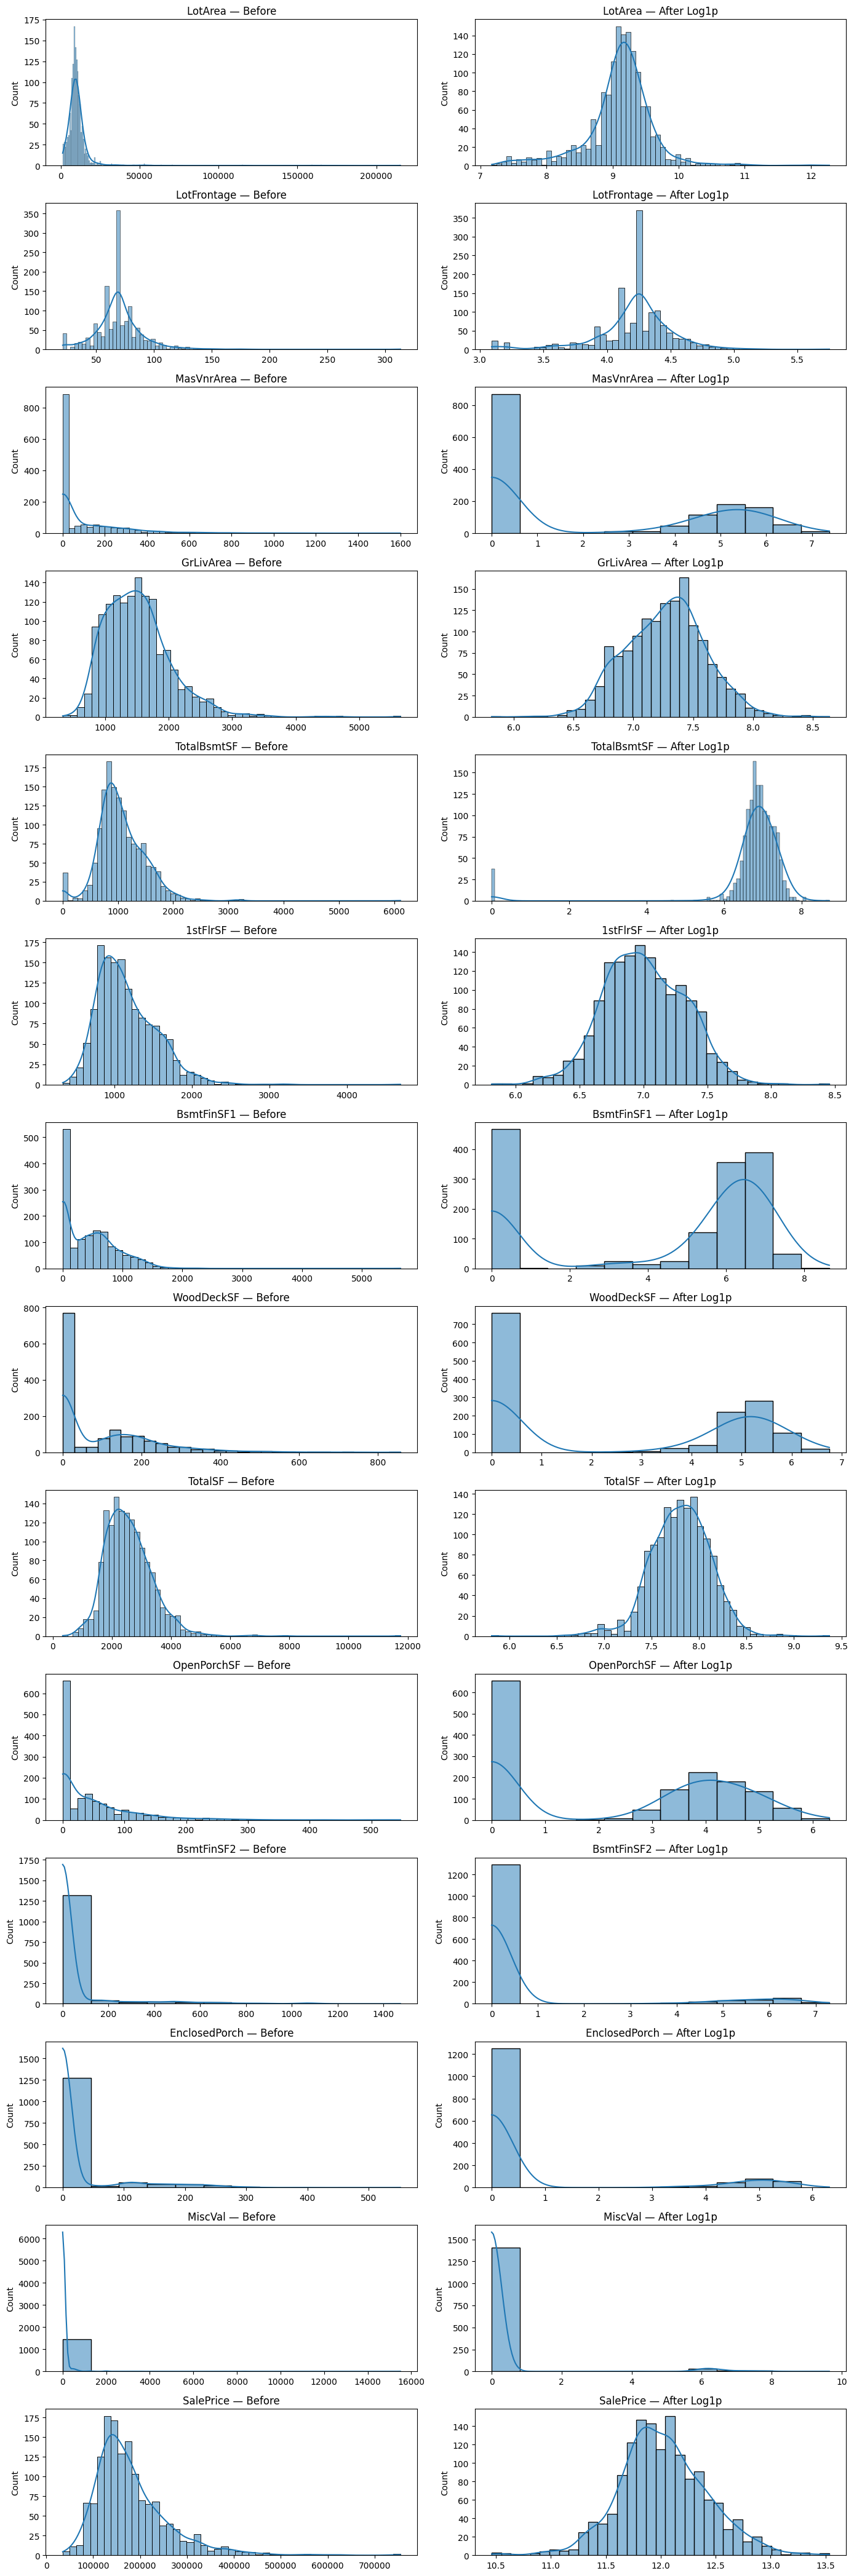

In [19]:
# Before and After Log1p Transformation
skewed_cols = [
    'LotArea', 'LotFrontage', 'MasVnrArea', 'GrLivArea',
    'TotalBsmtSF', '1stFlrSF', 'BsmtFinSF1', 'WoodDeckSF', 'TotalSF',
    'OpenPorchSF', 'BsmtFinSF2', 'EnclosedPorch', 'MiscVal', 'SalePrice'
]

fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, len(skewed_cols) * 3))

for i, col in enumerate(skewed_cols):
    # Before
    sns.histplot(train_df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — Before')
    axes[i, 0].set_xlabel('')

    # After
    sns.histplot(np.log1p(train_df[col]), kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — After Log1p')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

In [20]:
# Apply final transformation
log_transform_cols = [
    'LotArea', 'LotFrontage', 'GrLivArea', 'TotalBsmtSF',
    '1stFlrSF', 'BsmtFinSF1', 'WoodDeckSF', 'OpenPorchSF',
    'BsmtFinSF2', 'EnclosedPorch', 'SalePrice', 'TotalSF'
]

train_df[log_transform_cols] = np.log1p(train_df[log_transform_cols])
test_cols = [col for col in log_transform_cols if col != 'SalePrice']
test_df[test_cols] = np.log1p(test_df[test_cols])

### **Correlation with SalePrice**

In [21]:
# Top 15 Positive and Negative Correlations with SalePrice
corr = train_df.select_dtypes(include='number').corr()['SalePrice'].drop('SalePrice')

print("Top 10 Positive Correlations:")
print(corr.sort_values(ascending=False).head(15))

print("\nTop 10 Negative Correlations:")
print(corr.sort_values().head(15))

Top 10 Positive Correlations:
TotalSF         0.807140
GrLivArea       0.730254
GarageCars      0.680625
ExterQual       0.678840
KitchenQual     0.667893
GarageArea      0.650888
BsmtQual        0.615804
1stFlrSF        0.608955
GarageFinish    0.604878
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
FireplaceQu     0.546362
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
Name: SalePrice, dtype: float64

Top 10 Negative Correlations:
LotShape        -0.286002
EnclosedPorch   -0.207263
KitchenAbvGr    -0.147548
LandSlope       -0.038526
LowQualFinSF    -0.037963
BsmtFinSF2      -0.030361
MiscVal         -0.020021
BsmtHalfBath    -0.005149
BsmtFinType2     0.014034
ExterCond        0.049313
3SsnPorch        0.054900
PoolArea         0.069798
ScreenPorch      0.121208
Functional       0.136294
BsmtFinSF1       0.208099
Name: SalePrice, dtype: float64


The strongest predictors of sale price are living area, garage size, and finish quality, confirming that both size and condition drive value. Negative correlations are weak across the board, suggesting price is driven more by positive features a home has rather than any single detractor.

### **Feature Engineering**

In [22]:
# TotalBath — Total bathroom count across the entire home
train_df['TotalBath'] = (train_df['FullBath'] + train_df['HalfBath'] +
train_df['BsmtFullBath'] + (train_df['BsmtHalfBath'] * 0.5))

test_df['TotalBath'] = (test_df['FullBath'] + test_df['HalfBath'] +
test_df['BsmtFullBath'] + (test_df['BsmtHalfBath'] * 0.5))

In [23]:
# HouseAge — Age of the home at time of sale
train_df['HouseAge'] = train_df['YrSold'] - train_df['YearBuilt']
test_df['HouseAge'] = test_df['YrSold'] - test_df['YearBuilt']

In [24]:
# YearsSinceRemodel — Years since last remodel at time of sale
train_df['YearsSinceRemodel'] = train_df['YrSold'] - train_df['YearRemodAdd']
test_df['YearsSinceRemodel'] = test_df['YrSold'] - test_df['YearRemodAdd']

In [25]:
# Binary flags for features that are mostly zero
train_df['HasPool'] = (train_df['PoolArea'] > 0).astype(int)
train_df['HasGarage'] = (train_df['GarageArea'] > 0).astype(int)
train_df['HasFireplace'] = (train_df['Fireplaces'] > 0).astype(int)
train_df['Has2ndFloor'] = (train_df['2ndFlrSF'] > 0).astype(int)

test_df['HasPool'] = (test_df['PoolArea'] > 0).astype(int)
test_df['HasGarage'] = (test_df['GarageArea'] > 0).astype(int)
test_df['HasFireplace'] = (test_df['Fireplaces'] > 0).astype(int)
test_df['Has2ndFloor'] = (test_df['2ndFlrSF'] > 0).astype(int)

In [26]:
# Cast to int — YrSold is object dtype so subtraction inherits object type
train_df['HouseAge'] = (train_df['YrSold'].astype(int) - train_df['YearBuilt'].astype(int))
train_df['YearsSinceRemodel'] = (train_df['YrSold'].astype(int) - train_df['YearRemodAdd'].astype(int))

test_df['HouseAge'] = (test_df['YrSold'].astype(int) - test_df['YearBuilt'].astype(int))
test_df['YearsSinceRemodel'] = (test_df['YrSold'].astype(int) - test_df['YearRemodAdd'].astype(int))

In [27]:
# Correlation of new features
new_features = ['TotalSF', 'TotalBath', 'HouseAge', 'YearsSinceRemodel',
                'HasPool', 'HasGarage', 'HasFireplace', 'Has2ndFloor']

corr = train_df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
print(corr.sort_values(ascending=False))

TotalSF              0.807140
TotalBath            0.664653
HasFireplace         0.510026
HasGarage            0.322998
Has2ndFloor          0.150549
HasPool              0.069835
YearsSinceRemodel   -0.568136
HouseAge            -0.587290
Name: SalePrice, dtype: float64


I'm drop the columns below because they have been replaced by more informative engineered features that either combine multiple columns into one stronger signal or reduce noise from features with near zero predictive value.

In [28]:
# Drop redundant and low value features
cols_to_drop = [
    '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF',
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    'YearBuilt', 'YearRemodAdd',
    'PoolArea', 'HasPool'
]

train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

### **Key Features vs SalePrice**

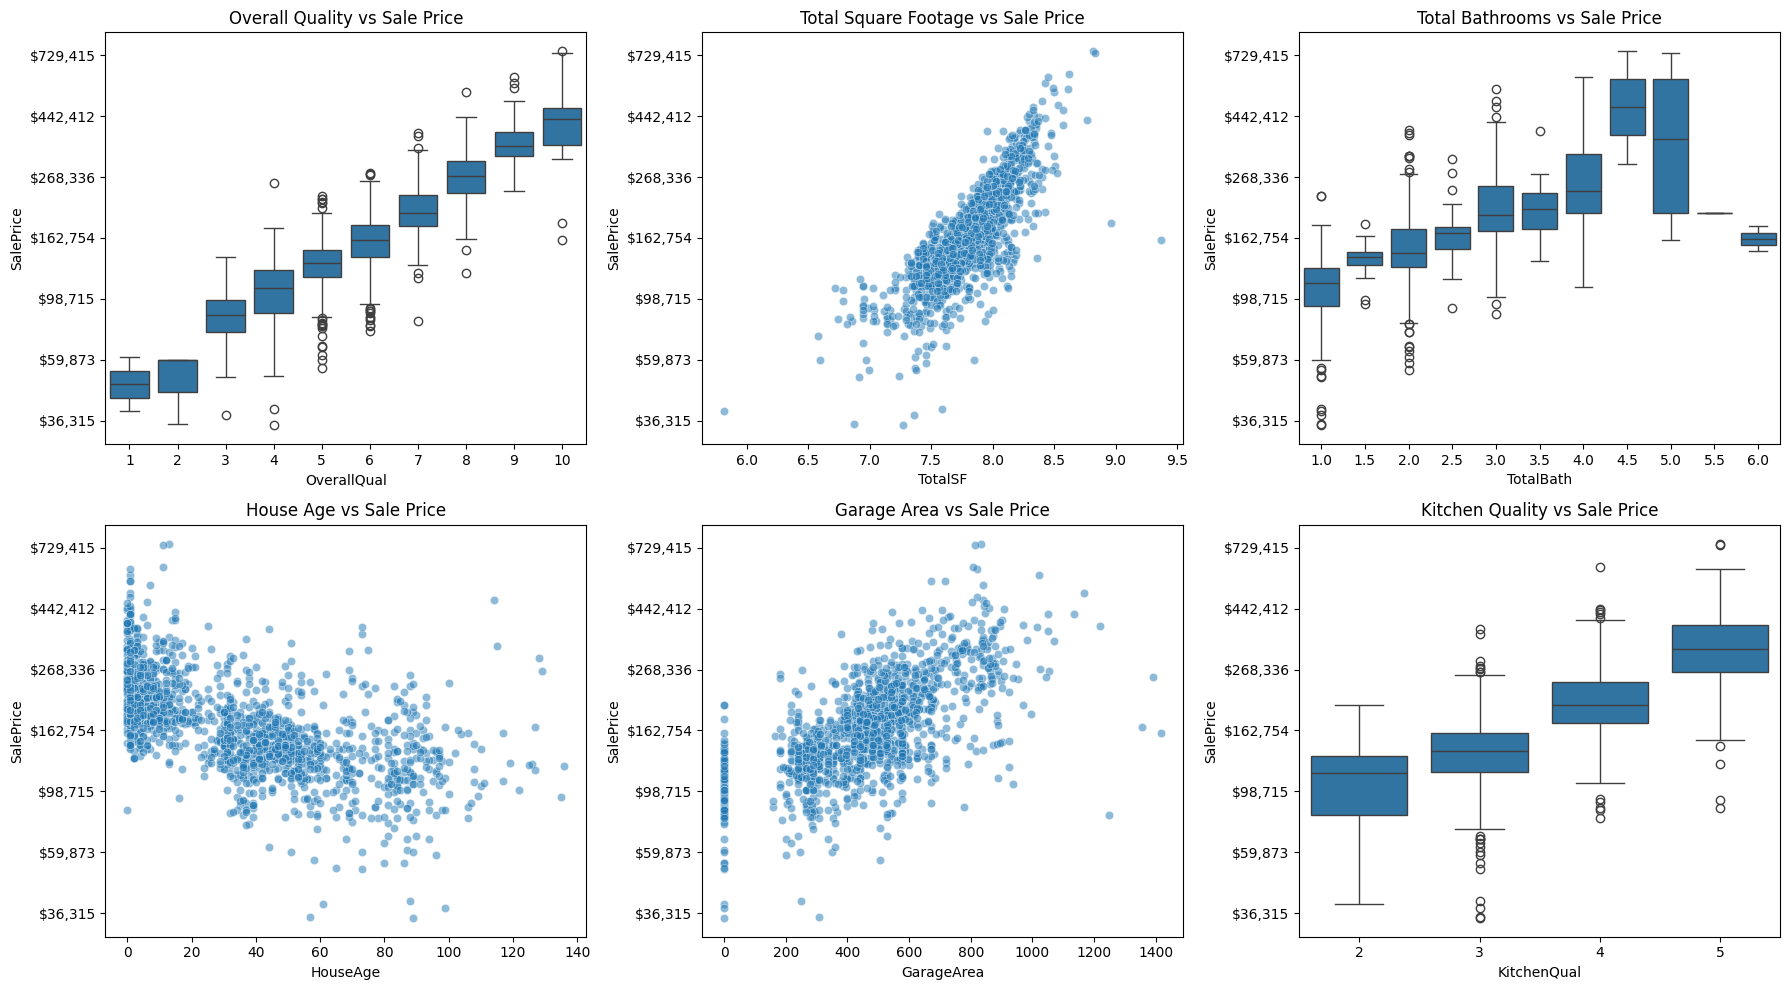

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# OverallQual vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=train_df, ax=axes[0, 0])
axes[0, 0].set_title('Overall Quality vs Sale Price')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

# TotalSF vs SalePrice
sns.scatterplot(x='TotalSF', y='SalePrice', data=train_df, alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Total Square Footage vs Sale Price')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

# TotalBath vs SalePrice
sns.boxplot(x='TotalBath', y='SalePrice', data=train_df, ax=axes[0, 2])
axes[0, 2].set_title('Total Bathrooms vs Sale Price')
axes[0, 2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

# HouseAge vs SalePrice
sns.scatterplot(x='HouseAge', y='SalePrice', data=train_df, alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('House Age vs Sale Price')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

# GarageArea vs SalePrice
sns.scatterplot(x='GarageArea', y='SalePrice', data=train_df, alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Garage Area vs Sale Price')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

# KitchenQual vs SalePrice
sns.boxplot(x='KitchenQual', y='SalePrice', data=train_df, ax=axes[1, 2])
axes[1, 2].set_title('Kitchen Quality vs Sale Price')
axes[1, 2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

plt.tight_layout()
plt.show()

###  **Neighborhood Analysis**

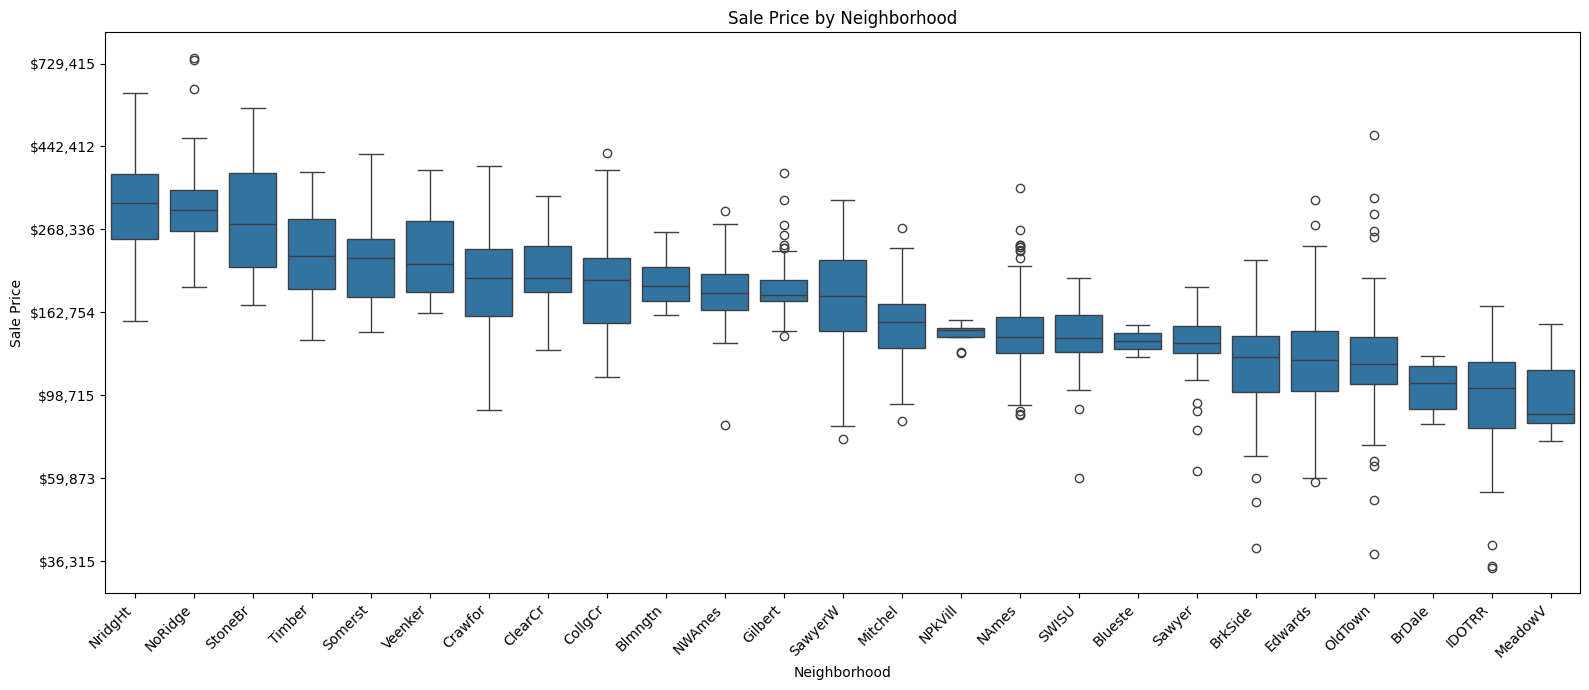

In [30]:
# Neighborhood Analysis
fig, ax = plt.subplots(figsize=(16, 7))

neighborhood_order = train_df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

sns.boxplot(x='Neighborhood', y='SalePrice', data=train_df, order=neighborhood_order, ax=ax)
ax.set_title('Sale Price by Neighborhood')
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Sale Price')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Top tier neighborhoods** — NridgHt, NoRidge, and StoneBr are clearly the premium areas with median prices around 300k+ and tight distributions meaning consistently high value.

**Middle tier** — Timber, Somerst, Veenker, and Crawfor cluster around 200k-250k with moderate variance.

**Bottom tier** — IDOTRR, BrDale, and MeadowV are the most affordable neighborhoods with medians around 100k and some very low outliers.

**Wide variance neighborhoods** — Gilbert and SawyerW have large boxes meaning price is inconsistent there, likely driven by a mix of home types and quality levels within the same neighborhood.

### **Outlier Detection**

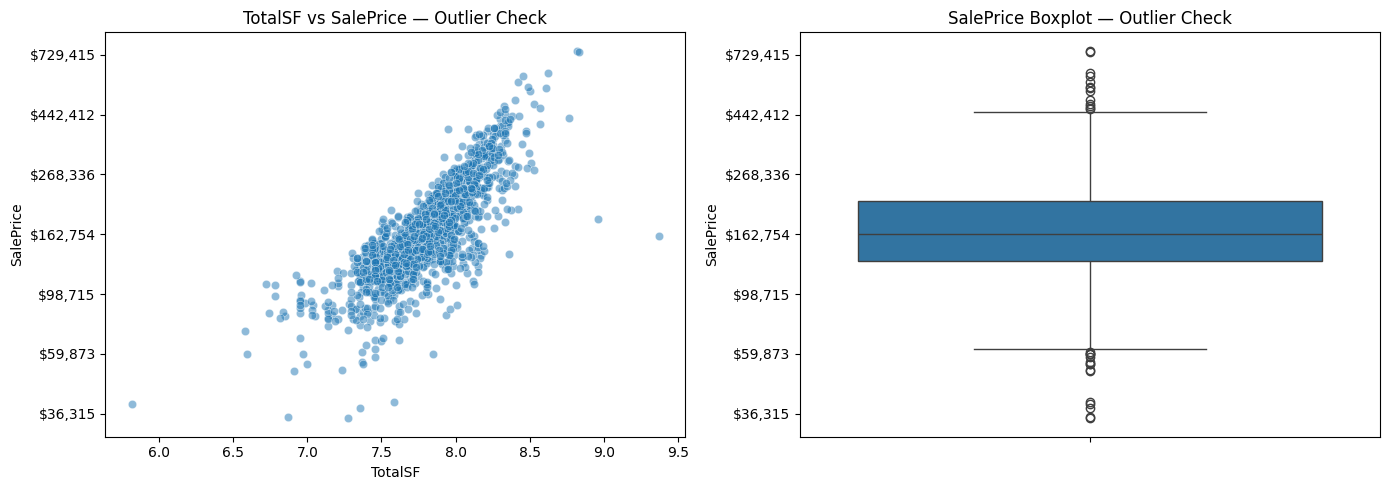

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TotalSF outliers
sns.scatterplot(x='TotalSF', y='SalePrice', data=train_df, alpha=0.5, ax=axes[0])
axes[0].set_title('TotalSF vs SalePrice — Outlier Check')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

# SalePrice boxplot
sns.boxplot(y='SalePrice', data=train_df, ax=axes[1])
axes[1].set_title('SalePrice Boxplot — Outlier Check')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${np.expm1(x):,.0f}'))

plt.tight_layout()
plt.show()

In [32]:
# Print potential outliers
outliers = train_df[(train_df['TotalSF'] > train_df['TotalSF'].quantile(0.99)) |
                    (train_df['SalePrice'] < train_df['SalePrice'].quantile(0.01))]
print(f"Potential outliers: {len(outliers)} rows")
print(outliers[['TotalSF', 'SalePrice']].sort_values('TotalSF', ascending=False))

Potential outliers: 30 rows
       TotalSF  SalePrice
1298  9.371864  11.982935
523   8.963800  12.126764
1182  8.835356  13.521141
691   8.818926  13.534474
496   8.768574  12.971543
1169  8.622994  13.345509
440   8.611958  13.226725
1353  8.570165  12.923915
1373  8.569216  13.053015
798   8.530504  13.091906
1044  8.526945  12.535380
304   8.509967  12.594734
769   8.503094  13.195616
118   8.496174  12.676079
1046  8.488999  13.229570
410   7.845024  11.002117
30    7.584265  10.596660
1380  7.455298  10.976799
1325  7.373374  10.915107
375   7.370231  11.018646
812   7.368340  10.933000
968   7.358194  10.542733
495   7.273093  10.460271
1337  7.234898  10.868587
705   6.996681  10.915107
636   6.970730  11.002117
710   6.907755  10.859018
916   6.867974  10.471978
1100  6.591674  11.002117
533   5.814131  10.579005


The scatter plot reveals a strong linear relationship between total square footage and sale price, but a handful of homes fall far outside the expected pattern. These are either distressed sales, data entry errors, or unusual transactions that could skew model training if left in.


Homes That Raise Suspicion

*   Row 1298 — largest home in the dataset by TotalSF (9.37) but sold for only 160k, a massive home at that price is almost certainly a distressed or abnormal sale

* Row 533 — smallest TotalSF in the outlier list (5.81) yet priced similarly to much larger homes, suggesting either a data error or an unusually premium small property

* Rows 691 and 1182 — both have very high TotalSF (8.8+) and very high prices above 750k, legitimate but worth monitoring as they could pull the model toward extreme predictions

* Rows 410, 30, 1380, 1325, 375, 812 — mid range TotalSF but prices clustering around 60k-80k which is well below what similar sized homes sold for, these could be family sales, foreclosures, or partial interest transactions

* Row 968 and 495 — reasonable size but prices near the bottom of the dataset, same concern as above

In [33]:
# Drop known outliers — large homes sold at suspiciously low prices
train_df = train_df.drop(train_df[(train_df['TotalSF'] > 8.8) &
                                   (train_df['SalePrice'] < 12.5)].index)

print(f"Remaining rows: {len(train_df)}")

Remaining rows: 1458


## **One-hot Encoding**

In [34]:
# One-Hot Encoding — nominal categorical columns
train_df = pd.get_dummies(train_df)
test_df = pd.get_dummies(test_df)

# Align train and test to ensure same columns after encoding
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

## **Trim the Dataset**

### **Drop low variance columns**

In [35]:
# Drop low variance columns — threshold of 0.01
selector = VarianceThreshold(threshold=0.01)
selector.fit(train_df.drop(columns='SalePrice'))

low_variance_cols = train_df.drop(columns='SalePrice').columns[~selector.get_support()].tolist()
print(f"Low variance columns to drop: {len(low_variance_cols)}")
print(low_variance_cols)

Low variance columns to drop: 70
['MSSubClass_40', 'MSSubClass_45', 'MSSubClass_180', 'MSZoning_C (all)', 'Street_Grvl', 'Street_Pave', 'Utilities_AllPub', 'Utilities_NoSeWa', 'LotConfig_FR3', 'Neighborhood_Blueste', 'Neighborhood_NPkVill', 'Neighborhood_Veenker', 'Condition1_PosA', 'Condition1_RRAe', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_Artery', 'Condition2_Feedr', 'Condition2_Norm', 'Condition2_PosA', 'Condition2_PosN', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'HouseStyle_1.5Unf', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'OverallQual_1', 'OverallQual_2', 'OverallCond_1', 'OverallCond_2', 'RoofStyle_Flat', 'RoofStyle_Gambrel', 'RoofStyle_Mansard', 'RoofStyle_Shed', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'RoofMatl_WdShngl', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_CBlock', 'Exterior1st_ImStucc', 'Exterior1st_Stone', 'Exterior2nd_AsphShn', 'Exterior2nd_Brk Cmn', 'Exterior2nd_CBlock', 

In [36]:
train_df = train_df.drop(columns=low_variance_cols)
test_df = test_df.drop(columns=low_variance_cols)

print(f"\nRemaining columns: {train_df.shape[1]}")


Remaining columns: 189


### **Check for multicollinearity**

In [37]:
# Check for multicollinearity — drop features correlated above 0.9
corr_matrix = train_df.drop(columns='SalePrice').corr().abs()

# Get upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with correlation above threshold
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.9)]

print(f"High correlation columns to drop: {len(high_corr_cols)}")
print(high_corr_cols)

High correlation columns to drop: 15
['GarageQual', 'GarageCond', 'HasGarage', 'HasFireplace', 'BldgType_2fmCon', 'BldgType_Duplex', 'HouseStyle_1.5Fin', 'HouseStyle_SLvl', 'RoofStyle_Hip', 'Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'CentralAir_Y', 'GarageType_None', 'SaleCondition_Partial']


In [38]:
# Drop high multicollinearity columns
train_df.drop(columns=high_corr_cols, inplace=True)
test_df.drop(columns=high_corr_cols, inplace=True)

print(f"Remaining columns: {train_df.shape[1]}")

Remaining columns: 174


### **Near zero correlation with SalePrice**

In [39]:
# Drop features with near zero correlation with SalePrice
corr_with_target = train_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values()
low_corr_cols = corr_with_target[corr_with_target < 0.02].index.tolist()

print(f"Low correlation columns to drop: {len(low_corr_cols)}")
print(low_corr_cols)

train_df.drop(columns=low_corr_cols, inplace=True)
test_df.drop(columns=[col for col in low_corr_cols if col in test_df.columns], inplace=True)

print(f"\nRemaining columns: {train_df.shape[1]}")

Low correlation columns to drop: 17
['MSSubClass_80', 'MoSold_10', 'LotConfig_Corner', 'MoSold_3', 'MoSold_6', 'LotConfig_FR2', 'LandContour_Lvl', 'MSSubClass_75', 'MoSold_2', 'Exterior1st_Plywood', 'YrSold_2008', 'Exterior2nd_BrkFace', 'BsmtFinType2', 'YrSold_2006', 'Condition1_RRAn', 'MoSold_8', 'MoSold_12']

Remaining columns: 157


In [40]:
# Quality Check
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Series([], dtype: int64)
BsmtFinSF1     1
BsmtFinSF2     1
BsmtUnfSF      1
KitchenQual    1
Functional     2
GarageCars     1
GarageArea     1
TotalSF        1
TotalBath      2
dtype: int64


In [41]:
# Fill remaining test nulls with train median
null_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'KitchenQual',
             'Functional', 'GarageCars', 'GarageArea', 'TotalSF', 'TotalBath']

for col in null_cols:
    test_df[col] = test_df[col].fillna(train_df[col].median())

## **Modeling**

### **Linear Regession**

In [42]:
# Linear Regression Baseline
X_train = train_df.drop(columns='SalePrice')
y_train = train_df['SalePrice']

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [43]:
lr = LinearRegression()

rmse_scores = np.sqrt(-cross_val_score(lr, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
r2_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='r2')

print(f"Linear Regression")
print(f"CV RMSE: {rmse_scores.mean():.4f} +/- {rmse_scores.std():.4f}")
print(f"CV R2:   {r2_scores.mean():.4f} +/- {r2_scores.std():.4f}")

lr.fit(X_train, y_train)
train_preds = lr.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f"Train RMSE: {train_rmse:.4f}")

Linear Regression
CV RMSE: 0.1128 +/- 0.0067
CV R2:   0.9195 +/- 0.0113
Train RMSE: 0.0951


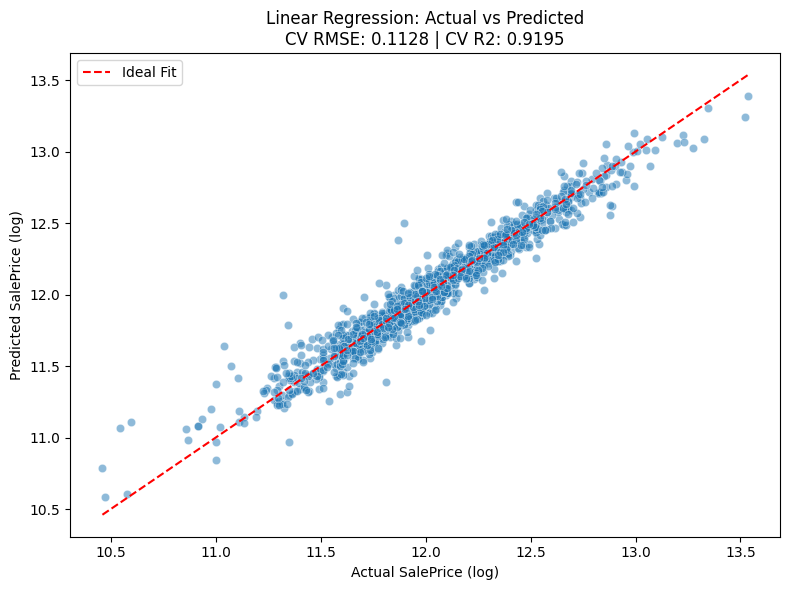

In [44]:
# Linear Regression — Actual vs Predicted
lr.fit(X_train, y_train)
train_preds = lr.predict(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train, y=train_preds, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual SalePrice (log)')
plt.ylabel('Predicted SalePrice (log)')
plt.title(f'Linear Regression: Actual vs Predicted\nCV RMSE: {rmse_scores.mean():.4f} | CV R2: {r2_scores.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.show()

#### **Ridge Regression**

In [45]:
# Ridge
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=cv)
ridge.fit(X_train, y_train)

ridge_rmse = np.sqrt(-cross_val_score(ridge, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
ridge_r2 = cross_val_score(ridge, X_train, y_train, cv=cv, scoring='r2')

print(f"Ridge Regression (alpha={ridge.alpha_})")
print(f"CV RMSE: {ridge_rmse.mean():.4f} +/- {ridge_rmse.std():.4f}")
print(f"CV R2:   {ridge_r2.mean():.4f} +/- {ridge_r2.std():.4f}")

Ridge Regression (alpha=1.0)
CV RMSE: 0.1125 +/- 0.0083
CV R2:   0.9200 +/- 0.0118


#### **Lasso Rergession**

In [46]:
# Lasso
lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], cv=cv, max_iter=10000)
lasso.fit(X_train, y_train)

lasso_rmse = np.sqrt(-cross_val_score(lasso, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
lasso_r2 = cross_val_score(lasso, X_train, y_train, cv=cv, scoring='r2')

print(f"\nLasso Regression (alpha={lasso.alpha_})")
print(f"CV RMSE: {lasso_rmse.mean():.4f} +/- {lasso_rmse.std():.4f}")
print(f"CV R2:   {lasso_r2.mean():.4f} +/- {lasso_r2.std():.4f}")


Lasso Regression (alpha=0.0001)
CV RMSE: 0.1112 +/- 0.0075
CV R2:   0.9218 +/- 0.0115


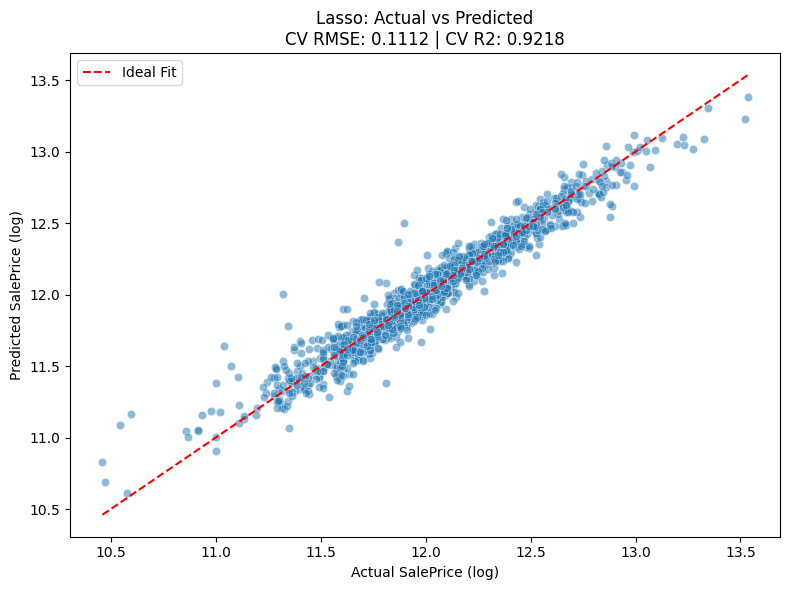

In [47]:
lasso_train_preds = lasso.predict(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train, y=lasso_train_preds, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual SalePrice (log)')
plt.ylabel('Predicted SalePrice (log)')
plt.title(f'Lasso: Actual vs Predicted\nCV RMSE: {lasso_rmse.mean():.4f} | CV R2: {lasso_r2.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.show()

Lasso is the best so far with a very small alpha meaning it is barely regularizing, which tells you the linear model was not heavily overfitting to begin with. The boosting models should improve on this significantly. Ready for XGBoost?

### **Polynomial Regression**

In [48]:
poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('model', LinearRegression())
])

poly_rmse = np.sqrt(-cross_val_score(poly, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
poly_r2 = cross_val_score(poly, X_train, y_train, cv=cv, scoring='r2')

print(f"Polynomial Regression (degree=2, interactions only)")
print(f"CV RMSE: {poly_rmse.mean():.4f} +/- {poly_rmse.std():.4f}")
print(f"CV R2:   {poly_r2.mean():.4f} +/- {poly_r2.std():.4f}")

Polynomial Regression (degree=2, interactions only)
CV RMSE: 0.6521 +/- 0.1767
CV R2:   -1.7701 +/- 1.3534


#### **Ploy + Ridge**

In [49]:
# Polynomial + RidgeCV
poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=cv))
])

poly_ridge_rmse = np.sqrt(-cross_val_score(poly_ridge, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
poly_ridge_r2 = cross_val_score(poly_ridge, X_train, y_train, cv=cv, scoring='r2')

print(f"Polynomial + RidgeCV")
print(f"CV RMSE: {poly_ridge_rmse.mean():.4f} +/- {poly_ridge_rmse.std():.4f}")
print(f"CV R2:   {poly_ridge_r2.mean():.4f} +/- {poly_ridge_r2.std():.4f}")

Polynomial + RidgeCV
CV RMSE: 0.5290 +/- 0.1791
CV R2:   -0.8723 +/- 1.2060


### **XGBoost**

In [50]:
# XGBoost RandomizedSearchCV
param_grid = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

xgb_base = xgb.XGBRegressor(random_state=11, n_jobs=-1, device='cuda')

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=cv,
    random_state=11,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"Best Parameters: {xgb_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-xgb_search.best_score_):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV RMSE: 0.1206


In [51]:
# Define Best model
best_model = xgb.XGBRegressor(
    **xgb_search.best_params_,
    random_state=11,
    n_jobs=-1,
    device='cuda'
)

# Out-of-fold predictions
y_oof_pred = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

# Fit on all training data for "train" predictions
best_model.fit(X_train, y_train)
y_train_pred = best_model.predict(X_train)

print("Train R2:", r2_score(y_train, y_train_pred))
print("CV (OOF) R2:", r2_score(y_train, y_oof_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("CV (OOF) RMSE:", np.sqrt(mean_squared_error(y_train, y_oof_pred)))

Train R2: 0.9668202915210654
CV (OOF) R2: 0.9089107654776899
Train RMSE: 0.0727839100478031
CV (OOF) RMSE: 0.12059592305470537


In [52]:
# Lock in best parameters
xgb_final = xgb.XGBRegressor(
    subsample=0.6,
    n_estimators=1134,
    min_child_weight=5,
    max_depth=4,
    learning_rate=0.01,
    colsample_bytree=0.8,
    random_state=11,
    device='cuda'
)

xgb_rmse = np.sqrt(-cross_val_score(xgb_final, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
xgb_r2 = cross_val_score(xgb_final, X_train, y_train, cv=cv, scoring='r2')

print(f"XGBoost Final")
print(f"CV RMSE: {xgb_rmse.mean():.4f} +/- {xgb_rmse.std():.4f}")
print(f"CV R2:   {xgb_r2.mean():.4f} +/- {xgb_r2.std():.4f}")

XGBoost Final
CV RMSE: 0.1206 +/- 0.0093
CV R2:   0.9087 +/- 0.0085


### **LightGBM**

In [53]:
# LightGBM RandomizedSearchCV
param_grid_lgb = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 4],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7],
    'min_child_samples': [10, 20, 30]
}

lgb_base = lgb.LGBMRegressor(random_state=11, n_jobs=1, verbose=-1)

lgb_search = RandomizedSearchCV(
    lgb_base,
    param_distributions=param_grid_lgb,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=cv,
    random_state=11,
    n_jobs=-1,
    verbose=1
)

lgb_search.fit(X_train, y_train)

print(f"Best Parameters: {lgb_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-lgb_search.best_score_):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 1500, 'min_child_samples': 10, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV RMSE: 0.1227


In [54]:
lgb_final = lgb.LGBMRegressor(
    subsample=0.6,
    n_estimators=1500,
    min_child_samples=10,
    max_depth=4,
    learning_rate=0.01,
    colsample_bytree=0.6,
    random_state=11,
    verbose=-1
)

lgb_rmse = np.sqrt(-cross_val_score(lgb_final, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
lgb_r2 = cross_val_score(lgb_final, X_train, y_train, cv=cv, scoring='r2')

print(f"LightGBM Final")
print(f"CV RMSE: {lgb_rmse.mean():.4f} +/- {lgb_rmse.std():.4f}")
print(f"CV R2:   {lgb_r2.mean():.4f} +/- {lgb_r2.std():.4f}")

LightGBM Final
CV RMSE: 0.1223 +/- 0.0097
CV R2:   0.9062 +/- 0.0086


### **Shap Values**

#### **XGBoost**

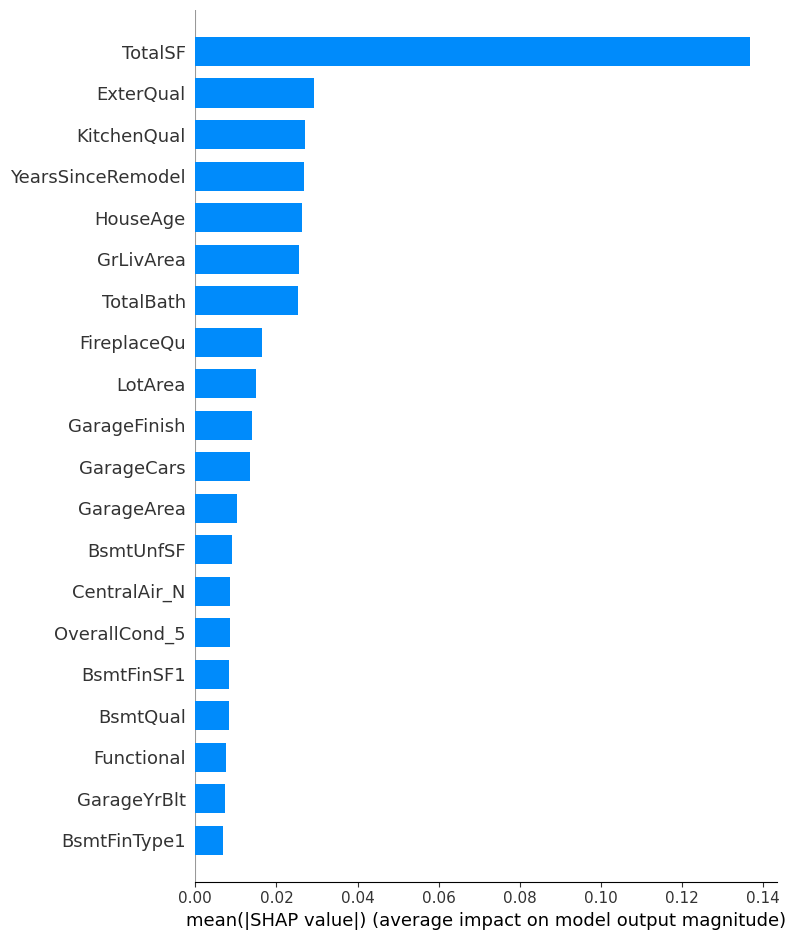

In [55]:
xgb_final.fit(X_train, y_train)
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_train)

# Summary plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_train, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.show()

#### **Lasso**

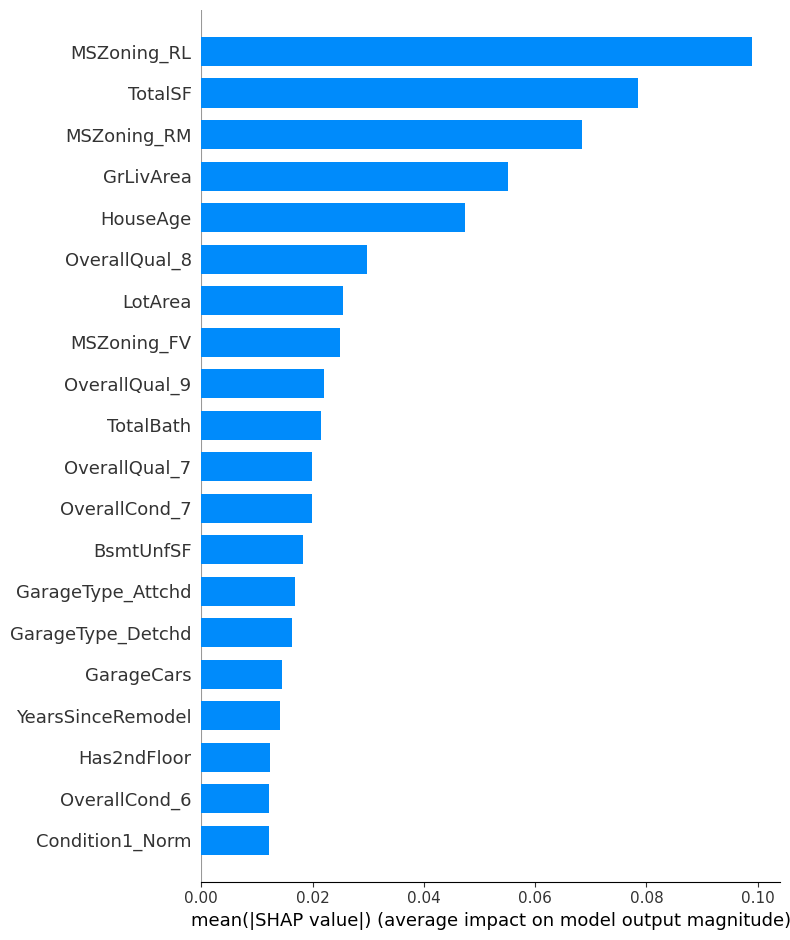

In [56]:
explainer = shap.LinearExplainer(lasso, X_train)
shap_values = explainer.shap_values(X_train)

# Summary plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_train, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.show()

Both models agree that total square footage and home quality are the primary drivers of sale price, confirming these as universally important features regardless of model type. Where they differ is notable — XGBoost surfaces finish quality features like ExterQual and KitchenQual prominently while Lasso leans heavily on zoning classification, suggesting that linear models pick up on broader neighborhood level signals while tree based models capture finer grained quality distinctions within properties.

### **Ensemble (Lasso + XGBoost)**

In [57]:
# Ensemble metrics on training data
lasso.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

lasso_train_preds = lasso.predict(X_train)
xgb_train_preds = xgb_final.predict(X_train)

ensemble_train_preds = (lasso_train_preds + xgb_train_preds) / 2

ensemble_rmse = np.sqrt(mean_squared_error(y_train, ensemble_train_preds))
ensemble_r2 = r2_score(y_train, ensemble_train_preds)

print(f"Ensemble Train Metrics")
print(f"Train RMSE: {ensemble_rmse:.4f}")
print(f"Train R2:   {ensemble_r2:.4f}")

Ensemble Train Metrics
Train RMSE: 0.0790
Train R2:   0.9609


In [58]:
lasso.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

lasso_train = lasso.predict(X_train)
xgb_train = xgb_final.predict(X_train)
ensemble_train = (lasso_train + xgb_train) / 2

ensemble_df = pd.DataFrame({
    'Actual': np.expm1(y_train),
    'Predicted_Lasso': np.expm1(lasso_train),
    'Predicted_XGBoost': np.expm1(xgb_train),
    'Predicted_Ensemble': np.expm1(ensemble_train),
    'Residual_Ensemble': np.expm1(y_train) - np.expm1(ensemble_train)
})

ensemble_df.to_csv('ensemble_predictions.csv', index=False)
print(ensemble_df.head())

     Actual  Predicted_Lasso  Predicted_XGBoost  Predicted_Ensemble  \
0  208500.0    205264.315088       202560.84375       203908.101575   
1  181500.0    185520.560031       171520.59375       178383.289697   
2  223500.0    215822.995023       216350.03125       216086.348795   
3  140000.0    164636.804743       152432.90625       158417.382573   
4  250000.0    310181.514185       283021.00000       296290.195315   

   Residual_Ensemble  
0        4591.898425  
1        3116.710303  
2        7413.651205  
3      -18417.382573  
4      -46290.195315  


Lasso outperformed XGBoost and LightGBM because L1 regularization and clean feature engineering created a strong linear signal that tree based models could not improve on with only 1460 rows. However the best result came from ensembling Lasso and XGBoost by averaging their predictions, which balanced Lasso's linear precision with XGBoost's ability to capture non-linear patterns and produced the lowest Kaggle score of 0.124.

### **Evaluate Ensamble on the test set**

In [59]:
X_test = test_df.drop(columns='SalePrice', errors='ignore')

In [60]:
lasso_preds = np.expm1(lasso.predict(X_test))
xgb_preds = np.expm1(xgb_final.predict(X_test))

ensemble_preds = (lasso_preds + xgb_preds) / 2

test_ids = test_raw['Id']

submission_ensemble = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': ensemble_preds
})

submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print(submission_ensemble.head())

     Id      SalePrice
0  1461  120690.277626
1  1462  160422.287238
2  1463  188510.044387
3  1464  194918.526239
4  1465  192708.716014


### **Model Summary Table**

In [61]:
# Final Model Comparison Summary
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Polynomial', 'Polynomial + Ridge', 'XGBoost', 'LightGBM', 'Ensemble'],
    'CV RMSE': [0.1128, 0.1125, 0.1112, 0.6521, 0.5290, 0.1205, 0.1223, 0.0786],
    'CV R2': [0.9195, 0.9200, 0.9218, -1.7701, -0.8723, 0.9088, 0.9062, 0.9613],
    'Kaggle Score': [None, None, 0.12846, None, None, 0.13000, None, 0.12400]
})

print(results.to_string(index=False))

             Model  CV RMSE   CV R2  Kaggle Score
 Linear Regression   0.1128  0.9195           NaN
             Ridge   0.1125  0.9200           NaN
             Lasso   0.1112  0.9218       0.12846
        Polynomial   0.6521 -1.7701           NaN
Polynomial + Ridge   0.5290 -0.8723           NaN
           XGBoost   0.1205  0.9088       0.13000
          LightGBM   0.1223  0.9062           NaN
          Ensemble   0.0786  0.9613       0.12400
